In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_squared_error, r2_score

In [2]:
housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["Price"] = housing.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

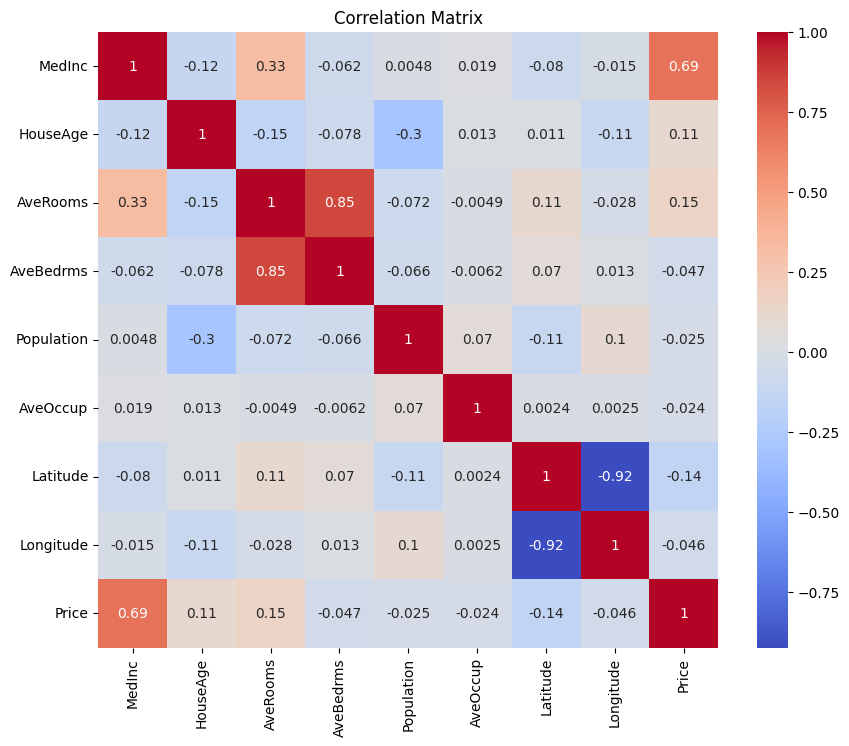

In [4]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [5]:
df["Rooms_per_Household"] = df["AveRooms"] / df["AveOccup"]
df["Bedrooms_per_Room"] = df["AveBedrms"] / df["AveRooms"]
df["Population_per_Household"] = df["Population"] / df["AveOccup"]

In [6]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price,Rooms_per_Household,Bedrooms_per_Room,Population_per_Household
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,2.732919,0.146591,126.0
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,2.956685,0.155797,1138.0
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,2.957661,0.129516,177.0
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,2.283154,0.184458,219.0
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,2.879646,0.172096,259.0


In [7]:
X = df.drop("Price", axis=1)
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [10]:
ridge = Ridge(alpha=100)
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

In [11]:
tree = DecisionTreeRegressor(max_depth=5)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

In [12]:
def evaluate_model(name, y_test, y_pred):
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(name)
    print("RMSE:", rmse)
    print("R2:", r2)
    print("------------------")

evaluate_model("Linear Regression", y_test, y_pred_lr)
evaluate_model("Ridge Regression", y_test, y_pred_ridge)
evaluate_model("Decision Tree", y_test, y_pred_tree)

Linear Regression
RMSE: 0.6738172773395145
R2: 0.6535205948827303
------------------
Ridge Regression
RMSE: 0.6745868617653663
R2: 0.6527286964430521
------------------
Decision Tree
RMSE: 0.7237712214616251
R2: 0.6002432906715391
------------------


In [13]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression", "Decision Tree"],
    "R2 Score": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_tree)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_test, y_pred_tree))
    ]
})

results

,Model,R2 Score,RMSE
0,Linear Regression,0.653521,0.673817
1,Ridge Regression,0.652729,0.674587
2,Decision Tree,0.600243,0.723771


In [18]:
from sklearn.ensemble import RandomForestRegressor

In [19]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=200, random_state=42)

In [20]:
y_pred_rf = rf.predict(X_test)

In [21]:
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest R2:", r2_rf)

Random Forest RMSE: 0.5441185188930943
Random Forest R2: 0.7740667474669978


In [22]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "R2 Score": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_tree),
        r2_rf
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_test, y_pred_tree)),
        rmse_rf
    ]
})

results

,Model,R2 Score,RMSE
0,Linear Regression,0.653521,0.673817
1,Ridge Regression,0.652729,0.674587
2,Decision Tree,0.600243,0.723771
3,Random Forest,0.774067,0.544119


In [ ]:
## Model Performance Comparison

Four regression models were trained and evaluated on the California Housing dataset.

Models tested:
- Linear Regression
- Ridge Regression
- Decision Tree Regressor
- Random Forest Regressor

Evaluation metrics:
- R² Score
- RMSE (Root Mean Squared Error)

Results show that Random Forest achieved the best performance with:

R² ≈ 0.77  
RMSE ≈ 0.54

This indicates that the Random Forest model explains about 77% of the variance in housing prices, significantly outperforming the linear models.

Linear Regression and Ridge Regression produced similar results, suggesting that regularization had minimal impact on this dataset.

Decision Tree performed worse due to overfitting and limited depth.

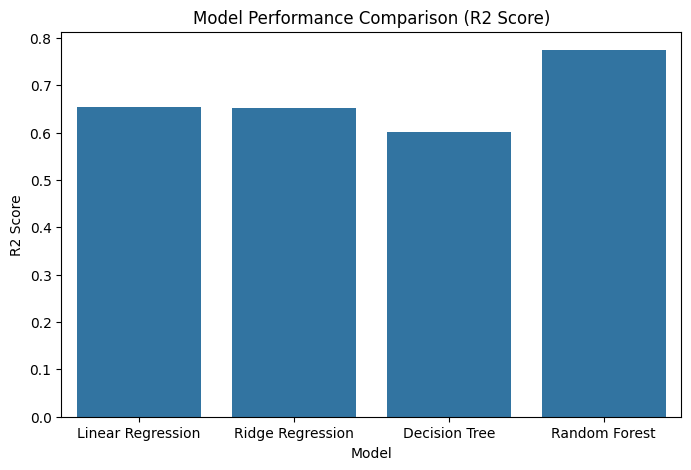

In [23]:
plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="R2 Score", data=results)
plt.title("Model Performance Comparison (R2 Score)")
plt.show()

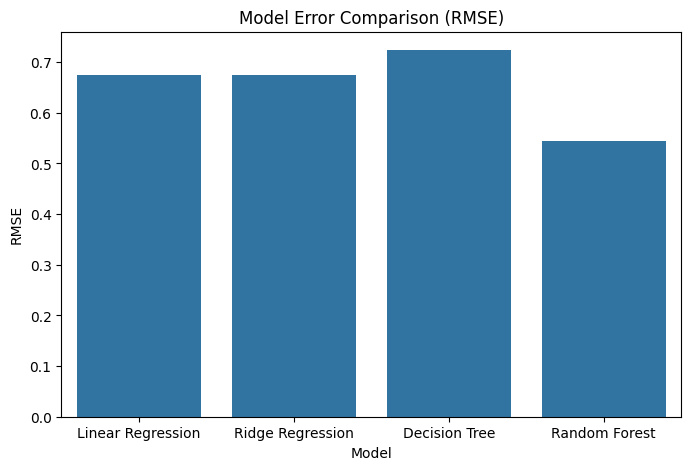

In [24]:
plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="RMSE", data=results)
plt.title("Model Error Comparison (RMSE)")
plt.show()

In [ ]:
## Key Insights

• Feature engineering improved model performance.

• Linear Regression captured basic relationships in the data.

• Ridge Regression produced similar results, indicating that regularization had minimal impact.

• Decision Tree captured non-linear patterns but showed higher prediction error.

• Random Forest significantly improved performance by combining multiple decision trees and reducing variance.

• Random Forest achieved the highest accuracy among all tested models.

In [ ]:
## Conclusion

In this task, we explored feature engineering, data preprocessing,
and machine learning model comparison.

Four regression models were implemented:

- Linear Regression
- Ridge Regression
- Decision Tree
- Random Forest

Random Forest Regressor achieved the best performance with R² ≈ 0.77,
demonstrating its ability to capture complex non-linear relationships
in the housing dataset.

This project demonstrates the full machine learning workflow including
data exploration, feature engineering, model training, and performance evaluation.

Future improvements may include hyperparameter tuning,
cross-validation, and advanced ensemble models.